In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [95]:
# Load by file name
R2502_2503 = pd.read_pickle("R2502_2503.pkl")
R2503_2502 = pd.read_pickle("R2503_2502.pkl")

F2504 = pd.read_pickle("2504.pkl")

In [96]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-B")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-B2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-B*DIFF-PRESS-15min.txt"):
    print("found:", p.name)


/home/seismic/AxialFetch/MJ03F-B → True (dir)
/home/seismic/AxialFetch/MJ03F-B/MJ03F-B2022DIFF-PRESS-15min.txt → True
found: MJ03F-B2023DIFF-PRESS-15min.txt
found: MJ03F-B2022DIFF-PRESS-15min.txt
found: MJ03F-B2021DIFF-PRESS-15min.txt
found: MJ03F-B2020DIFF-PRESS-15min.txt
found: MJ03F-B2019DIFF-PRESS-15min.txt
found: MJ03F-B2018DIFF-PRESS-15min.txt
found: MJ03F-B2017DIFF-PRESS-15min.txt
found: MJ03F-B2024DIFF-PRESS-15min.txt


In [97]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['central_p']= (cp['depth']/0.67)

In [98]:
cp

,time,rawpsi,depth,temp,central_p
5677936,2016-01-01 00:00:00,2256.9014,1511.6279,2.777386,2256.161045
5677937,2016-01-01 00:00:15,2256.8966,1511.6246,2.777327,2256.156119
5677938,2016-01-01 00:00:30,2256.8918,1511.6212,2.777256,2256.151045
5677939,2016-01-01 00:00:45,2256.8927,1511.6217,2.777218,2256.151791
5677940,2016-01-01 00:01:00,2256.8937,1511.6221,2.777155,2256.152388
...,...,...,...,...,...
5677931,2024-12-31 23:58:45,2252.9795,1509.8760,2.756053,2253.546269
5677932,2024-12-31 23:59:00,2252.9797,1509.8787,2.755997,2253.550299
5677933,2024-12-31 23:59:15,2252.9751,1509.8783,2.755930,2253.549701
5677934,2024-12-31 23:59:30,2252.9686,1509.8766,2.755880,2253.547164


Rows in df_pressure: 2552


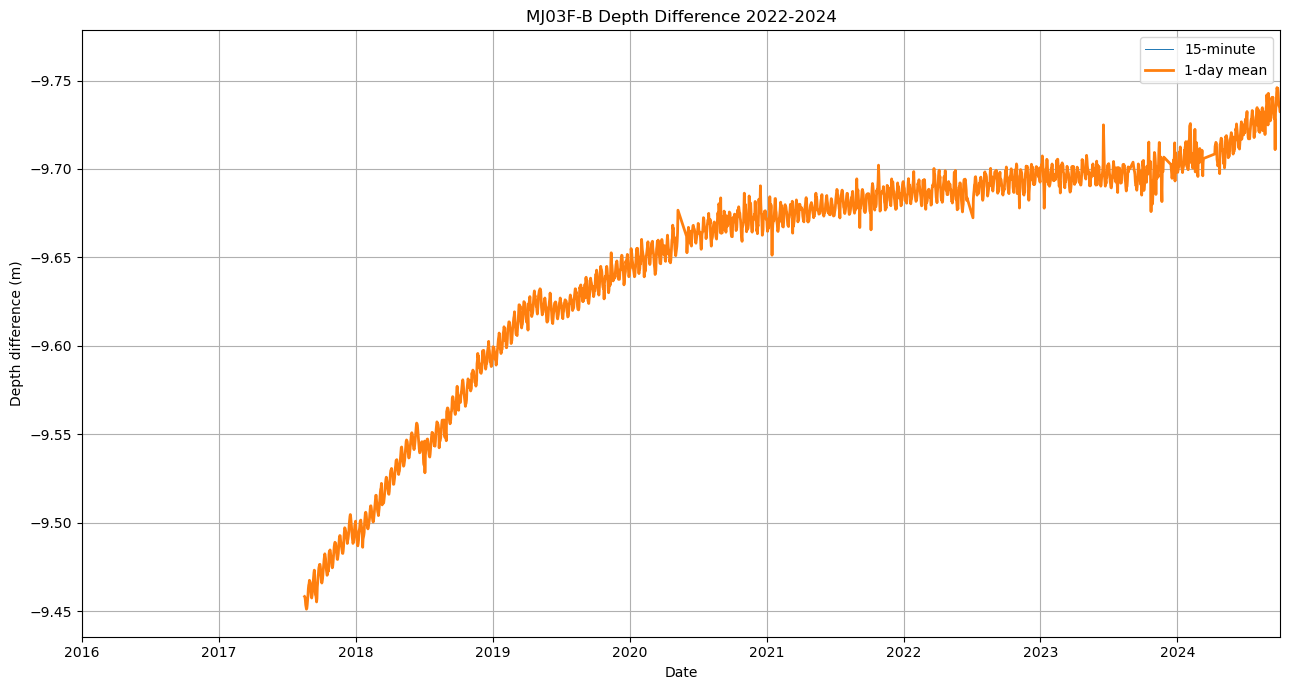

In [99]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-B")
years     = range(2016, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2016, 1, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
#plt.ylim(-14.55, -14.45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

del df_1day

Rows in df_pressure: 2552


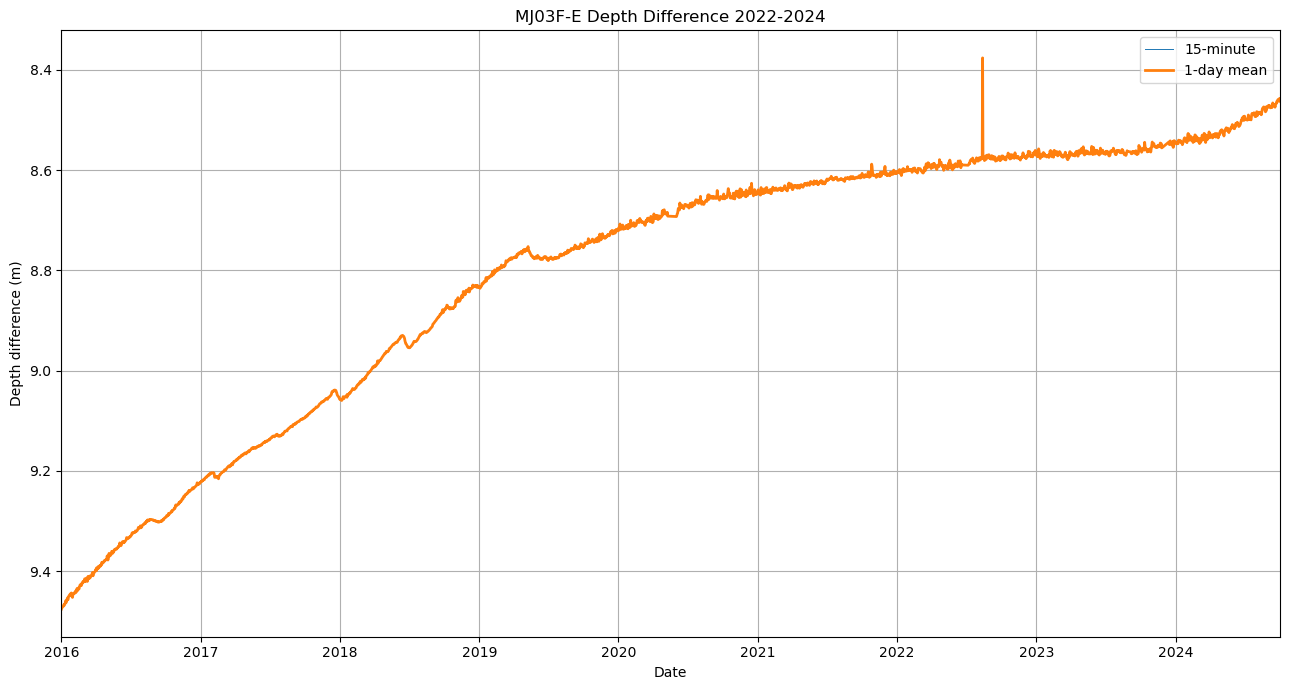

In [100]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2016, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure1 = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2016, 1, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Rows in df_pressure: 2552


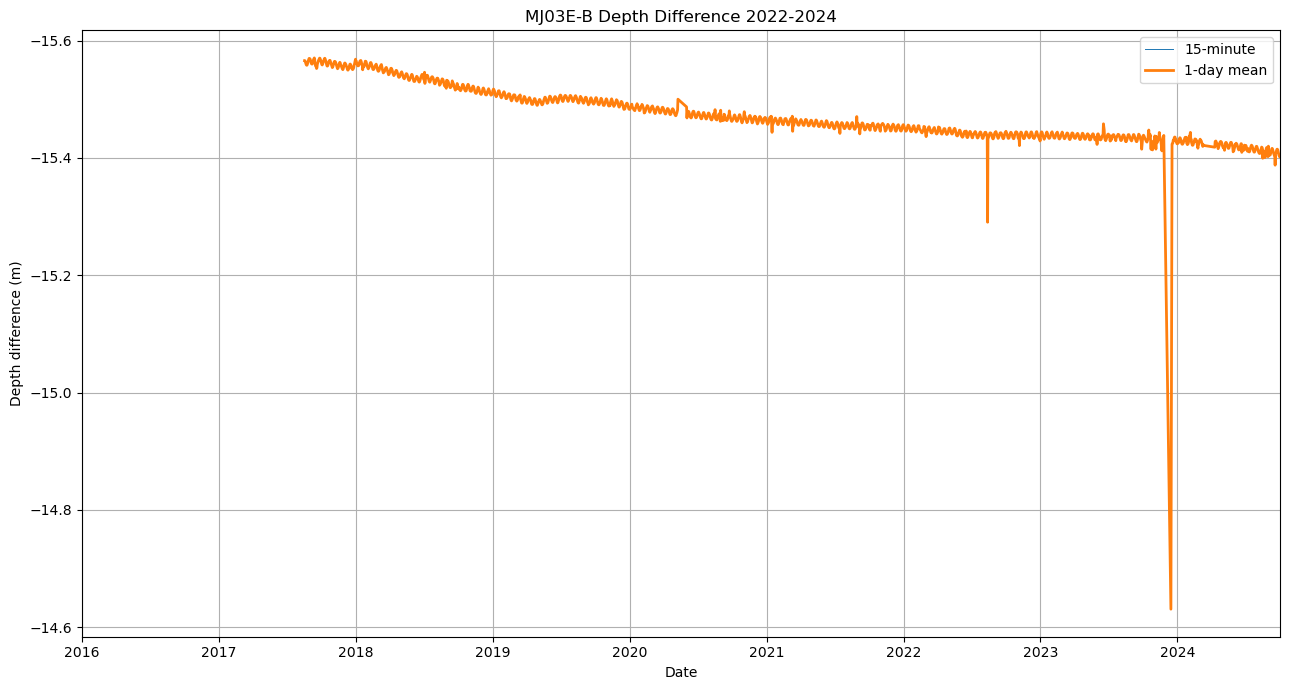

In [101]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03E-B")
years     = range(2016, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03E-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03E-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure2 = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03E-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2016, 1, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [102]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s


# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
pd1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

pd2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)




# -- 2. create cp1 (central pressure) ----------------------------------------
cp1 = (
    cp
        .assign(time=pd.to_datetime(cp["time"], utc=True))
        .set_index("time")["central_p"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 3. combine, align on common timestamps, compute p1 = cp1 – dp ----------
pressure_df = (
    pd.concat({"cp1": cp1,  "pd2": pd2}, axis=1)   # align on DateTime index
      .dropna(subset=["cp1", "pd2"])             # keep rows where BOTH exist
)



In [103]:
pressure_df

,cp1,pd2
time,,
2016-01-01 00:00:00+00:00,2256.161045,14.143040
2016-01-02 00:00:00+00:00,2256.174925,14.140357
2016-01-03 00:00:00+00:00,2256.161194,14.137693
2016-01-04 00:00:00+00:00,2256.175522,14.136605
2016-01-05 00:00:00+00:00,2256.152687,14.135539
...,...,...
2024-12-27 00:00:00+00:00,2253.466866,12.584945
2024-12-28 00:00:00+00:00,2253.490896,12.590025
2024-12-29 00:00:00+00:00,2253.546567,12.580734


In [104]:
# ------------------------------------------------------------------
# 0)  PREP – copy & add depth column just once
# ------------------------------------------------------------------
df = pressure_df.copy()
df.index = pd.to_datetime(df.index)

In [105]:
df

,cp1,pd2
time,,
2016-01-01 00:00:00+00:00,2256.161045,14.143040
2016-01-02 00:00:00+00:00,2256.174925,14.140357
2016-01-03 00:00:00+00:00,2256.161194,14.137693
2016-01-04 00:00:00+00:00,2256.175522,14.136605
2016-01-05 00:00:00+00:00,2256.152687,14.135539
...,...,...
2024-12-27 00:00:00+00:00,2253.466866,12.584945
2024-12-28 00:00:00+00:00,2253.490896,12.590025
2024-12-29 00:00:00+00:00,2253.546567,12.580734


In [106]:
# ------------------------------------------------------------------
# 1)  FUNCTION: change over an arbitrary interval
# ------------------------------------------------------------------
def interval_change(df, start, end, days=7):
    """
    Compute 7-day-median change for depth, pd1, pd2
    between *start* and *end* (inclusive).

    Parameters
    ----------
    df : DataFrame with columns cp1 (kPa), pd1, pd2, depth_m
    start, end : str or pandas-compatible timestamps
    days : int, size of median window at each edge

    Returns
    -------
    Series with Δdepth_m, Δpd1_psi, Δpd2_psi, depth_per_pd2
    """
    # slice the DataFrame
    block = df.loc[start:end]
    if block.empty or len(block) < 2 * days:
        raise ValueError("Interval too short or outside data range.")

    first = block.iloc[:days].median()
    last  = block.iloc[-days:].median()
    diff  = last - first

    out = pd.Series({
        "cp1_psi": diff["cp1"],
        "Δpd2_psi": diff["pd2"],
    })
    out["ratio"] = out["cp1_psi"] / out["Δpd2_psi"]
    return out

# ------------------------------------------------------------------
# 2)  EXAMPLES
# ------------------------------------------------------------------
# Single interval
result = interval_change(df, "2022-09-01", "2024-09-01")
#print(result.round(4))

# Multiple intervals in a loop
intervals = [
    ("2017-08-17", "2020-06-01"),
    ("2022-09-01", "2024-10-01"),
]
summary = pd.DataFrame(
    [interval_change(df, s, e) for s, e in intervals],
    index=[f"{s} → {e}" for s, e in intervals]
)
print(summary.round(4))


                         cp1_psi  Δpd2_psi   ratio
2017-08-17 → 2020-06-01  -1.2228   -0.6380  1.9168
2022-09-01 → 2024-10-01  -0.2184   -0.1713  1.2747


In [107]:
df

,cp1,pd2
time,,
2016-01-01 00:00:00+00:00,2256.161045,14.143040
2016-01-02 00:00:00+00:00,2256.174925,14.140357
2016-01-03 00:00:00+00:00,2256.161194,14.137693
2016-01-04 00:00:00+00:00,2256.175522,14.136605
2016-01-05 00:00:00+00:00,2256.152687,14.135539
...,...,...
2024-12-27 00:00:00+00:00,2253.466866,12.584945
2024-12-28 00:00:00+00:00,2253.490896,12.590025
2024-12-29 00:00:00+00:00,2253.546567,12.580734


In [108]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s


# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
pd1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

pd2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)




# -- 2. create cp1 (central pressure) ----------------------------------------
cp1 = (
    cp
        .assign(time=pd.to_datetime(cp["time"], utc=True))
        .set_index("time")["central_p"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 3. combine, align on common timestamps, compute p1 = cp1 – dp ----------
pressure_df = (
    pd.concat({"cp1": cp1, "pd1": pd1, "pd2": pd2}, axis=1)   # align on DateTime index
      .dropna(subset=["cp1","pd1", "pd2"])             # keep rows where BOTH exist
)



In [109]:
# ------------------------------------------------------------------
# 0)  PREP – copy & add depth column just once
# ------------------------------------------------------------------
df = pressure_df.copy()
df.index = pd.to_datetime(df.index)

In [110]:
df

,cp1,pd1,pd2
time,,,
2017-08-17 00:00:00+00:00,2255.265075,-14.116840,13.606529
2017-08-18 00:00:00+00:00,2255.281642,-14.116385,13.605939
2017-08-19 00:00:00+00:00,2255.284776,-14.113936,13.604699
2017-08-20 00:00:00+00:00,2255.279403,-14.109848,13.604663
2017-08-21 00:00:00+00:00,2255.262687,-14.107969,13.602738
...,...,...,...
2024-12-27 00:00:00+00:00,2253.466866,-14.562579,12.584945
2024-12-28 00:00:00+00:00,2253.490896,-14.559589,12.590025
2024-12-29 00:00:00+00:00,2253.546567,-14.563757,12.580734


In [111]:
# ------------------------------------------------------------------
# 1)  FUNCTION: change over an arbitrary interval
# ------------------------------------------------------------------
def interval_change(df, start, end, days=7):
    """
    Compute 7-day-median change for depth, pd1, pd2
    between *start* and *end* (inclusive).

    Parameters
    ----------
    df : DataFrame with columns cp1 (kPa), pd1, pd2, depth_m
    start, end : str or pandas-compatible timestamps
    days : int, size of median window at each edge

    Returns
    -------
    Series with Δdepth_m, Δpd1_psi, Δpd2_psi, depth_per_pd2
    """
    # slice the DataFrame
    block = df.loc[start:end]
    if block.empty or len(block) < 2 * days:
        raise ValueError("Interval too short or outside data range.")

    first = block.iloc[:days].median()
    last  = block.iloc[-days:].median()
    diff  = last - first

    out = pd.Series({
        "cp1_psi": diff["cp1"],
        "Δpd1_psi": diff["pd1"],
    })
    out["ratio"] = out["cp1_psi"] / out["Δpd1_psi"]
    return out


# Multiple intervals in a loop
intervals = [
    ("2017-08-17", "2020-06-01"),
    ("2020-01-01", "2022-09-01"),
    ("2022-09-01", "2024-10-01"),
    ("2017-08-17", "2024-12-31"),
]
summary = pd.DataFrame(
    [interval_change(df, s, e) for s, e in intervals],
    index=[f"{s} → {e}" for s, e in intervals]
)
print(summary.round(4))


                         cp1_psi  Δpd1_psi   ratio
2017-08-17 → 2020-06-01  -1.2228   -0.3023  4.0449
2020-01-01 → 2022-09-01  -0.3628   -0.0678  5.3546
2022-09-01 → 2024-10-01  -0.2184   -0.0561  3.8930
2017-08-17 → 2024-12-31  -1.7700   -0.4527  3.9096


In [112]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s


# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
pd1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

pd2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

pd3 = (
    df_pressure2.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)



# -- 2. create cp1 (central pressure) ----------------------------------------
cp1 = (
    cp
        .assign(time=pd.to_datetime(cp["time"], utc=True))
        .set_index("time")["central_p"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 3. combine, align on common timestamps, compute p1 = cp1 – dp ----------
pressure_df = (
    pd.concat({"cp1": cp1, "pd1": pd1, "pd2": pd2, "pd3":pd3}, axis=1)   # align on DateTime index
      .dropna(subset=["cp1","pd1", "pd2", "pd3"])             # keep rows where BOTH exist
)

# ------------------------------------------------------------------
# 0)  PREP – copy & add depth column just once
# ------------------------------------------------------------------
df = pressure_df.copy()
df.index = pd.to_datetime(df.index)

In [113]:
df

,cp1,pd1,pd2,pd3
time,,,,
2017-08-17 00:00:00+00:00,2255.265075,-14.116840,13.606529,-23.124053
2017-08-18 00:00:00+00:00,2255.281642,-14.116385,13.605939,-23.121147
2017-08-19 00:00:00+00:00,2255.284776,-14.113936,13.604699,-23.121221
2017-08-20 00:00:00+00:00,2255.279403,-14.109848,13.604663,-23.120890
2017-08-21 00:00:00+00:00,2255.262687,-14.107969,13.602738,-23.122537
...,...,...,...,...
2023-03-15 00:00:00+00:00,2253.794328,-14.475919,12.794122,-22.993059
2023-03-16 00:00:00+00:00,2253.841194,-14.474854,12.789369,-22.993663
2023-03-17 00:00:00+00:00,2253.836866,-14.473325,12.786198,-22.992051


In [114]:
# ------------------------------------------------------------------
# 1)  FUNCTION: change over an arbitrary interval
# ------------------------------------------------------------------
def interval_change(df, start, end, days=7):
    """
    Compute 7-day-median change for depth, pd1, pd2
    between *start* and *end* (inclusive).

    Parameters
    ----------
    df : DataFrame with columns cp1 (kPa), pd1, pd2, depth_m
    start, end : str or pandas-compatible timestamps
    days : int, size of median window at each edge

    Returns
    -------
    Series with Δdepth_m, Δpd1_psi, Δpd2_psi, depth_per_pd2
    """
    # slice the DataFrame
    block = df.loc[start:end]
    if block.empty or len(block) < 2 * days:
        raise ValueError("Interval too short or outside data range.")

    first = block.iloc[:days].median()
    last  = block.iloc[-days:].median()
    diff  = last - first

    out = pd.Series({
        "cp1_psi": diff["cp1"],
        "Δpd3_psi": diff["pd3"],
    })
    out["ratio"] = out["cp1_psi"] / out["Δpd3_psi"]
    return out


# Multiple intervals in a loop
intervals = [
    ("2017-08-17", "2020-06-01"),
    ("2020-01-01", "2022-09-01"),
    ("2022-09-01", "2024-10-01"),
    ("2017-08-17", "2024-12-31"),
]
summary = pd.DataFrame(
    [interval_change(df, s, e) for s, e in intervals],
    index=[f"{s} → {e}" for s, e in intervals]
)
print(summary.round(4))


                         cp1_psi  Δpd3_psi    ratio
2017-08-17 → 2020-06-01  -1.2228    0.0685 -17.8644
2020-01-01 → 2022-09-01  -0.3628    0.0639  -5.6818
2022-09-01 → 2024-10-01  -0.0206    0.0245  -0.8402
2017-08-17 → 2024-12-31  -1.4669    0.1315 -11.1549


In [115]:
pressure_df["ep"] = pressure_df["cp1"] - (pressure_df["pd1"]*6.89476)
pressure_df["wp"] = pressure_df["cp1"] - (pressure_df["pd2"]*6.89476)
# -- 4. tidy up columns -------------------------------------------------------
#pressure_df.index.name = "Datetime"             # give index a name
#pressure_df = pressure_df.reset_index()[["Datetime", "p1", "p2","cp1"]]

#p1 = to_series(pressure_df, "Datetime", "p1")
#p2 = to_series(pressure_df, "Datetime", "p2")
#p3 = to_series(pressure_df, "Datetime", "cp1")

In [116]:
df = pressure_df.copy()
df.index = pd.to_datetime(df.index)

In [117]:
# ------------------------------------------------------------------
# 1)  FUNCTION: change over an arbitrary interval
# ------------------------------------------------------------------
def interval_change(df, start, end, days=30):
    """
    Compute 7-day-median change for depth, pd1, pd2
    between *start* and *end* (inclusive).

    Parameters
    ----------
    df : DataFrame with columns cp1 (kPa), pd1, pd2, depth_m
    start, end : str or pandas-compatible timestamps
    days : int, size of median window at each edge

    Returns
    -------
    Series with Δdepth_m, Δpd1_psi, Δpd2_psi, depth_per_pd2
    """
    # slice the DataFrame
    block = df.loc[start:end]
    if block.empty or len(block) < 2 * days:
        raise ValueError("Interval too short or outside data range.")

    first = block.iloc[:days].median()
    last  = block.iloc[-days:].median()
    diff  = last - first

    out = pd.Series({
        "Δcp_psi": diff["cp1"],
        "Δep_psi": diff["ep"],
        "Δwp_psi": diff["wp"],
    })
    return out


# Multiple intervals in a loop
intervals = [
    ("2017-08-17", "2020-06-01"),
    ("2022-09-01", "2024-10-01"),
]
summary = pd.DataFrame(
    [interval_change(df, s, e) for s, e in intervals],
    index=[f"{s} → {e}" for s, e in intervals]
)
print(summary.round(4))


                         Δcp_psi  Δep_psi  Δwp_psi
2017-08-17 → 2020-06-01  -1.1655   0.8762   3.1405
2022-09-01 → 2024-10-01  -0.0859  -0.0439   0.0040


In [118]:
pressure_df

,cp1,pd1,pd2,pd3,ep,wp
time,,,,,,
2017-08-17 00:00:00+00:00,2255.265075,-14.116840,13.606529,-23.124053,2352.597298,2161.451326
2017-08-18 00:00:00+00:00,2255.281642,-14.116385,13.605939,-23.121147,2352.610727,2161.471959
2017-08-19 00:00:00+00:00,2255.284776,-14.113936,13.604699,-23.121221,2352.596980,2161.483638
2017-08-20 00:00:00+00:00,2255.279403,-14.109848,13.604663,-23.120890,2352.563418,2161.478520
2017-08-21 00:00:00+00:00,2255.262687,-14.107969,13.602738,-23.122537,2352.533746,2161.475074
...,...,...,...,...,...,...
2023-03-15 00:00:00+00:00,2253.794328,-14.475919,12.794122,-22.993059,2353.602317,2165.581929
2023-03-16 00:00:00+00:00,2253.841194,-14.474854,12.789369,-22.993663,2353.641835,2165.661567
2023-03-17 00:00:00+00:00,2253.836866,-14.473325,12.786198,-22.992051,2353.626966,2165.679100
